# Food Delivery Funnel & Retention Analysis

**Objective:** locate the largest drop-off point in a food-delivery app's order funnel, check
whether it affects all user segments equally, and measure how many first-time orderers keep
ordering in the weeks after.

**Data:** session-level funnel events for delivery apps are not publicly available, so this
notebook runs on a simulated dataset of 60,000 users. Stage conversion rates are assumptions
and are listed in Section 1. The analysis itself is written the way it would run on production
event data.

**Tools:** Python (pandas, NumPy, matplotlib).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

N = 60_000

users = pd.DataFrame({"user_id": np.arange(1, N + 1)})
users["signup_week"] = rng.integers(0, 12, N)
users["city_tier"] = rng.choice(["Tier 1", "Tier 2", "Tier 3"], N, p=[0.50, 0.35, 0.15])
users["device"] = rng.choice(["Android", "iOS"], N, p=[0.70, 0.30])

print("rows:", len(users))
users.head()

rows: 60000


,user_id,signup_week,city_tier,device
0,1,1,Tier 1,Android
1,2,9,Tier 1,Android
2,3,7,Tier 3,iOS
3,4,5,Tier 1,Android
4,5,5,Tier 1,iOS


## 1. Building the funnel

Four sequential stages: opened the app, searched, added to cart, placed an order. A user can
only reach a stage if they cleared the one before it, so each stage is conditioned on the
previous one.

Baseline conversion assumptions:

| Stage | Conversion from previous stage |
| --- | --- |
| Opened app | 82% of all users |
| Searched | 68% |
| Added to cart | 45% |
| Placed order | 62% |

Two multipliers sit on top of the cart and order stages so the funnel is not uniform across
users: Tier-1 cities have denser restaurant supply and shorter delivery times, and iOS users
skew higher-income. Both are modelled as small adjustments centred on 1.0, which leaves the
overall funnel at the baseline rates above.

In [2]:
tier_effect = users["city_tier"].map({"Tier 1": 1.06, "Tier 2": 0.98, "Tier 3": 0.88})
device_effect = users["device"].map({"Android": 0.98, "iOS": 1.05})
effect = (tier_effect * device_effect).to_numpy()

users["opened_app"] = rng.random(N) < 0.82
users["searched"] = users["opened_app"] & (rng.random(N) < 0.68)
users["added_cart"] = users["searched"] & (rng.random(N) < 0.45 * effect)
users["placed_order"] = users["added_cart"] & (rng.random(N) < 0.62 * effect)

stages = ["opened_app", "searched", "added_cart", "placed_order"]

funnel = pd.DataFrame({"stage": stages, "users": [int(users[s].sum()) for s in stages]})
funnel["pct_of_top"] = (funnel["users"] / funnel["users"].iloc[0] * 100).round(1)
funnel["step_conv"] = (funnel["users"] / funnel["users"].shift(1) * 100).round(1)
funnel

,stage,users,pct_of_top,step_conv
0,opened_app,49173,100.0,NaN
1,searched,33304,67.7,67.7
2,added_cart,15149,30.8,45.5
3,placed_order,9502,19.3,62.7


## 2. Funnel shape

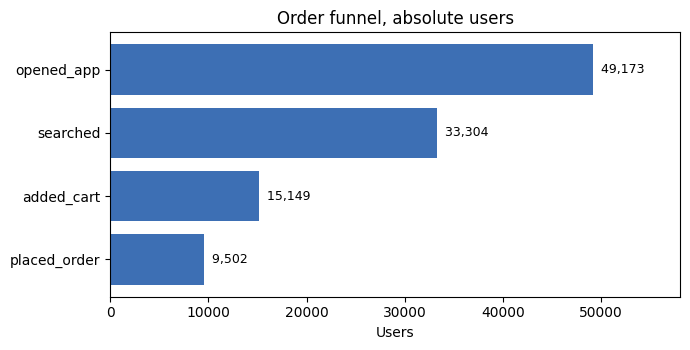

Open-to-order conversion: 19.3%


In [3]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(funnel["stage"][::-1], funnel["users"][::-1], color="#3d6fb4")
for i, v in enumerate(funnel["users"][::-1]):
    ax.text(v, i, f"  {v:,}", va="center", fontsize=9)
ax.set_xlim(0, funnel["users"].max() * 1.18)
ax.set_xlabel("Users")
ax.set_title("Order funnel, absolute users")
plt.tight_layout()
plt.show()

overall = funnel["users"].iloc[-1] / funnel["users"].iloc[0] * 100
print(f"Open-to-order conversion: {overall:.1f}%")

## 3. Locating the biggest leak

`step_conv` is the share of users who survive each step, so `100 - step_conv` is the drop-off
at that step. Ranking steps by drop-off shows which one costs the most users.

In [4]:
funnel["dropoff_pct"] = (100 - funnel["step_conv"]).round(1)

leaks = (funnel.iloc[1:][["stage", "step_conv", "dropoff_pct"]]
         .sort_values("dropoff_pct", ascending=False))
worst = leaks.iloc[0]

print(leaks.to_string(index=False))
print(f"\nLargest drop-off: {worst['stage']} ({worst['dropoff_pct']}% of users lost)")

       stage  step_conv  dropoff_pct
  added_cart       45.5         54.5
placed_order       62.7         37.3
    searched       67.7         32.3

Largest drop-off: added_cart (54.5% of users lost)


Search to add-to-cart is the largest single leak. These users have already shown intent by
searching and then leave without building a cart, which points at the results page rather than
at acquisition. The usual candidates are thin or poorly ranked results, delivery fees and
minimum-order values that only surface late, and long delivery estimates.

This step is also the most valuable one to fix because it sits further up the funnel: the same
percentage-point gain here passes through more users than an equivalent gain at checkout.

## 4. Segmenting conversion

A single average can hide a problem that is concentrated in one group. Splitting open-to-order
conversion by city tier and by device shows whether the leak is uniform.

In [5]:
def conversion_by(col):
    g = users.groupby(col).agg(opened=("opened_app", "sum"),
                               ordered=("placed_order", "sum"))
    g["conversion_pct"] = (g["ordered"] / g["opened"] * 100).round(1)
    return g

print(conversion_by("city_tier").to_string(), "\n")
print(conversion_by("device").to_string())

           opened  ordered  conversion_pct
city_tier                                 
Tier 1      24323     5207            21.4
Tier 2      17433     3185            18.3
Tier 3       7417     1110            15.0 

         opened  ordered  conversion_pct
device                                  
Android   34411     6473            18.8
iOS       14762     3029            20.5


In [6]:
seg = (users.groupby(["city_tier", "device"])
       .agg(opened=("opened_app", "sum"), ordered=("placed_order", "sum")))
seg["conversion_pct"] = (seg["ordered"] / seg["opened"] * 100).round(1)
seg["conversion_pct"].unstack()

device,Android,iOS
city_tier,,
Tier 1,20.9,22.7
Tier 2,17.9,19.1
Tier 3,14.2,16.8


## 5. Retention cohorts

Conversion only measures the first order. The business case for a delivery app rests on repeat
ordering, so users who placed an order are grouped by signup week and tracked over the
following four weeks. A user counts as retained in a given week only if they also ordered in
the previous week, so the curve reflects continuous activity rather than any order at all.

Weekly return probability is set at 50% for Tier 1, 42% for Tier 2 and 33% for Tier 3.

In [7]:
converters = users[users["placed_order"]].copy()
weekly_return = converters["city_tier"].map({"Tier 1": 0.50, "Tier 2": 0.42, "Tier 3": 0.33}).to_numpy()

WEEKS = 5
active = np.ones((len(converters), WEEKS), dtype=bool)
for w in range(1, WEEKS):
    active[:, w] = active[:, w - 1] & (rng.random(len(converters)) < weekly_return)

week_cols = [f"W{w}" for w in range(WEEKS)]
activity = pd.DataFrame(active, columns=week_cols)
activity["cohort_week"] = converters["signup_week"].to_numpy()
activity["city_tier"] = converters["city_tier"].to_numpy()

retention = (activity.groupby("cohort_week")[week_cols].mean() * 100).round(1)
retention

,W0,W1,W2,W3,W4
cohort_week,,,,,
0,100.0,44.5,22.0,9.6,5.1
1,100.0,44.4,20.3,9.9,5.0
2,100.0,46.8,21.3,10.2,4.8
3,100.0,44.2,20.4,9.6,3.9
4,100.0,46.7,22.2,9.5,4.9
5,100.0,45.6,21.8,10.5,4.5
6,100.0,46.5,23.5,11.2,6.0
7,100.0,48.2,20.5,10.2,4.5
8,100.0,47.8,20.3,9.8,4.4


Each row is a signup week and each column is weeks since signup. The rows are flat: no cohort
retains materially better than another. That is worth stating explicitly, because it means the
drop-off is structural to the product lifecycle rather than tied to a particular signup week,
so the fix is lifecycle re-engagement rather than anything cohort-specific.

Splitting the same table by city tier does show a gap.

In [8]:
retention_by_tier = (activity.groupby("city_tier")[week_cols].mean() * 100).round(1)
retention_by_tier

,W0,W1,W2,W3,W4
city_tier,,,,,
Tier 1,100.0,50.6,24.9,12.2,6.6
Tier 2,100.0,43.7,19.6,8.2,3.0
Tier 3,100.0,33.5,10.0,3.8,0.7


## 6. Retention curve

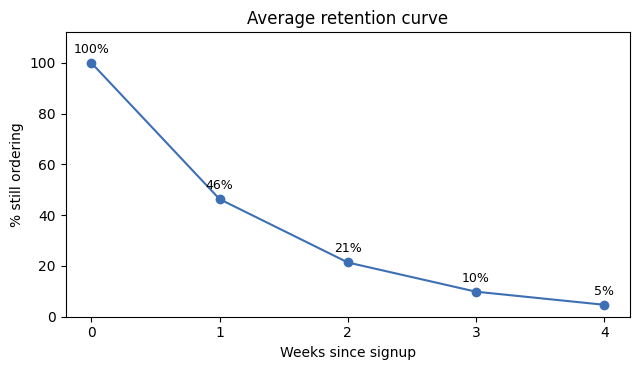

Week 1 retention: 46.3%
Week 4 retention: 4.7%


In [9]:
avg_curve = retention.mean()

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(range(WEEKS), avg_curve.values, marker="o", color="#3d6fb4")
for i, v in enumerate(avg_curve.values):
    ax.text(i, v + 4, f"{v:.0f}%", ha="center", fontsize=9)
ax.set_ylim(0, 112)
ax.set_xticks(range(WEEKS))
ax.set_xlabel("Weeks since signup")
ax.set_ylabel("% still ordering")
ax.set_title("Average retention curve")
plt.tight_layout()
plt.show()

print(f"Week 1 retention: {retention['W1'].mean():.1f}%")
print(f"Week 4 retention: {retention['W4'].mean():.1f}%")

## Findings and recommendations

**Where the funnel loses users.** Open-to-order conversion is 19.3%. Search to add-to-cart is
the largest leak at 54.5%, ahead of cart to order (37.3%) and open to search (32.3%). Because
the search step sits higher in the funnel, one percentage point recovered there is worth about
1.4x the same gain at checkout in absolute orders (33,304 users reach search against 15,149 who
reach the cart).

**Who is affected.** The leak is not uniform. Tier 1 converts at 21.4%, Tier 2 at 18.3% and
Tier 3 at 15.0%, so a Tier-3 user is roughly 30% less likely to order than a Tier-1 user. iOS
converts 1.7 points above Android (20.5% against 18.8%), and the tier gap holds inside both
platforms, which makes city tier the stronger of the two effects.

**Repeat ordering.** 46% of first-time orderers order again in week 1 and 4.7% are still
ordering in week 4. Cohort rows are flat across all twelve signup weeks, so the decay is a
property of the lifecycle rather than of any particular intake. The tier split is where
retention genuinely diverges: Tier 1 holds 6.6% at week 4 against 0.7% for Tier 3, which means
Tier-3 acquisition is largely buying users who order once and stop.

**Tests worth running**

| Priority | Hypothesis | Change to test | Primary metric | Guardrail |
| --- | --- | --- | --- | --- |
| 1 | Cost is discovered too late, so users abandon after searching | Surface delivery fee, delivery time and minimum order on the search result card instead of only inside the restaurant page | search to add-to-cart rate | cart to order rate, in case the abandonment simply moves upstream |
| 2 | Results are relevant but not orderable | Re-rank search results by availability and delivery time, not relevance alone | search to add-to-cart rate | average delivery time, cancellation rate |
| 3 | The re-engagement window is too late | Trigger the post-first-order offer on day 3 instead of day 7 | week-1 retention | promotion cost per retained user |

Tier 3 is deliberately not on that list. Before any interface test runs there, the question to
answer is whether Tier-3 searches return fewer available restaurants than Tier-1 searches. If
the constraint is restaurant supply, no change to the results page will move it, and the
spending decision is about onboarding merchants rather than about the funnel.

**Limitations.** The dataset is simulated, so the absolute figures follow from the assumptions
in Section 1 and should not be read as benchmarks. What transfers is the method: measure each
funnel step, rank the steps by lost users, segment before trusting the average, and treat
retention rather than first conversion as the success metric. On production data the same code
would run against session-level events, with order value and cancellations added so the funnel
could be weighted by revenue instead of user counts.